### LIBRARIES :

In [1]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

### READ THE DATASET :

### Task 1.1 : Load and Inspect Data

In [2]:
# Load the dataset and display the first 10 rows.
df = pd.read_csv('Railway_info.csv', encoding='utf-8', header=0)

df.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
5,421,LKO-SVDK FTR,LUCKNOW JN.,SHRI MATA VAISHNO DEVI KATRA,Tuesday
6,422,SVDK-LKO FTR,SHRI MATA VAISHNO DEVI KATRA,LUCKNOW JN.,Monday
7,477,FTR TRAIN NO,SIRSA,SIRSA,Sunday
8,502,RJPB-UMB FTR,RAJENDRANAGAR TERMINAL,AMBALA CANTT JN,Monday
9,504,PNBE-BTI FTR,PATNA JN.,BATHINDA JN,Wednesday


In [3]:
df.tail(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
11103,99835,LNL-PUNE EMU,LONAVLA,PUNE JN.,Tuesday
11104,99836,PUNE-TGN EMU,PUNE JN.,LONAVLA,Saturday
11105,99901,TGN-PUNE EMU,TALEGAON,PUNE JN.,Tuesday
11106,99902,PUNE-TGN EMU,PUNE JN.,TALEGAON,Sunday
11107,99903,TGN-PUNE EMU,TALEGAON,PUNE JN.,Wednesday
11108,99904,PUNE-TGN EMU,PUNE JN.,TALEGAON,Tuesday
11109,99905,EMU,TALEGAON,SHIVAJINAGAR,Monday
11110,99906,EMU,PUNE JN.,TALEGAON,Wednesday
11111,99907,EMU,TALEGAON,PUNE JN.,Thursday
11112,99908,EMU,PUNE JN.,TALEGAON,Sunday


### EDA ON DATASET :

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Train_No                  11113 non-null  int64 
 1   Train_Name                11113 non-null  object
 2   Source_Station_Name       11113 non-null  object
 3   Destination_Station_Name  11113 non-null  object
 4   days                      11113 non-null  object
dtypes: int64(1), object(4)
memory usage: 434.2+ KB


In [5]:
df.isnull().sum()

,0
Train_No,0
Train_Name,0
Source_Station_Name,0
Destination_Station_Name,0
days,0


In [6]:
df.duplicated().sum()

0

In [7]:
df.shape

(11113, 5)

In [8]:
df.describe()

,Train_No
count,11113.000000
mean,49190.570413
std,28515.986645
min,107.000000
25%,22607.000000
50%,47174.000000
75%,68012.000000
max,99908.000000


In [9]:
df.columns

Index(['Train_No', 'Train_Name', 'Source_Station_Name',
       'Destination_Station_Name', 'days'],
      dtype='object')

In [10]:
df.nunique()

,0
Train_No,11113
Train_Name,7580
Source_Station_Name,921
Destination_Station_Name,924
days,14


In [11]:
df.dtypes

,0
Train_No,int64
Train_Name,object
Source_Station_Name,object
Destination_Station_Name,object
days,object


In [12]:
df['Train_Name'].unique()

array(['SWV-MAO-VLNK', 'VLNK-MAO-SWV', 'MAO-KOP SPEC', ...,
       'PUNE-TGN EMU', 'TGN-PUNE EMU', 'EMU'], dtype=object)

In [13]:
df['Source_Station_Name'].unique()

array(['SAWANTWADI ROAD', 'MADGOAN JN.', 'DELHI-SAFDAR JANG',
       'AURANGABAD', 'LUCKNOW JN.', 'SHRI MATA VAISHNO DEVI KATRA',
       'SIRSA', 'RAJENDRANAGAR TERMINAL', 'PATNA JN.', 'URKURA',
       'NEW DELHI', 'CST-MUMBAI', 'LOKMANYA TILAK TERMINUS', 'AJNI',
       'KARMALI', 'NAGPUR JN.(CR)', 'PUNE JN.', 'MANGALORE JN',
       'JABALPUR', 'BANDRA TERMINUS', 'ATARI JN', 'SANTRAGACHI JN.',
       'REWA', 'BHOPAL', 'TRIVANDRUM CENTRAL', 'PALANI', 'POLLACHI',
       'HYDERABAD DECCAN', 'JAIPUR JN.', 'RAJKOT', 'CHENNAI CENTRAL',
       'HATIA', 'KOLKATA', 'PURI', 'ASANSOL MAIN', 'DHANBAD JN.',
       'KUSUNDA', 'SONARDIH', 'PHULWARTANR', 'JASIDIH JN.',
       'ANAND VIHAR TERMINAL', 'DELHI JN.', 'HAZRAT NIZAMUDDIN JN',
       'BIKANER JN.', 'HARIDWAR JN', 'HANUMANGARH JN.', 'SHRI GANGANAGAR',
       'SADULPUR JN', 'SURATGARH JN.', 'PARVATSAR CITY', 'MAKRANA JN.',
       'JODHPUR JN.', 'MERTA ROAD JN.', 'RATANAGARH JN', 'CHURU',
       'SAHARANPUR JN.', 'AMBALA CANTT JN', 'PATHANKOT JN

In [14]:
df['Destination_Station_Name'].unique()

array(['MADGOAN JN.', 'SAWANTWADI ROAD',
       'CHHATRAPATI SHAHU MAHARAJ TERMINUS', 'DELHI-SAFDAR JANG',
       'VARANASI JN.', 'SHRI MATA VAISHNO DEVI KATRA', 'LUCKNOW JN.',
       'SIRSA', 'AMBALA CANTT JN', 'BATHINDA JN', 'PATIALA', 'PANJIPARA',
       'SHMATA VD KATRA', 'AMRITSAR JN.', 'NAGPUR JN.(CR)',
       'LOKMANYA TILAK TERMINUS', 'KARMALI', 'AJNI', 'CST-MUMBAI',
       'MANGALORE JN', 'PUNE JN.', 'KHADKI', 'JABALPUR',
       'BANDRA TERMINUS', 'ATARI JN', 'SANTRAGACHI JN.', 'BHOPAL', 'REWA',
       'SILCHAR', 'POLLACHI', 'PALANI', 'JAIPUR JN.', 'HYDERABAD DECCAN',
       'RAJKOT', 'CHENNAI CENTRAL', 'HATIA', 'PURI', 'KOLKATA',
       'DHANBAD JN.', 'ASANSOL MAIN', 'KUSUNDA', 'PHULWARTANR',
       'SONARDIH', 'ANAND VIHAR TERMINAL', 'JASIDIH JN.', 'DELHI JN.',
       'HAZRAT NIZAMUDDIN JN', 'HARIDWAR JN', 'BIKANER JN.',
       'SHRI GANGANAGAR', 'HANUMANGARH JN.', 'SADULPUR JN',
       'SURATGARH JN.', 'MAKRANA JN.', 'PARVATSAR CITY', 'JODHPUR JN.',
       'RATANAGARH JN', 

In [15]:
df['days'].unique()

array(['Saturday', 'Friday', 'Wednesday', 'Tuesday', 'Monday', 'Sunday',
       'Thursday', 'Mondayd', 'Thursdayd', 'Tuesdayd', 'Fridayd',
       'Wednesdayd', 'Saturdayd', 'Sundayd'], dtype=object)

In [16]:
df['days'] = df['days'].str.replace('d$', '', regex=True)

### Task 1.2. Basic Statistics

In [17]:
# Number of trains
num_trains = df['Train_No'].nunique()

# Unique source and destination stations
unique_sources = df['Source_Station_Name'].nunique()
unique_destinations = df['Destination_Station_Name'].nunique()

# Most common source and destination stations
most_common_source = df['Source_Station_Name'].mode()[0]
most_common_destination = df['Destination_Station_Name'].mode()[0]

print(f"Number of trains: {num_trains}")
print(f"Unique source stations: {unique_sources}")
print(f"Unique destination stations: {unique_destinations}")
print(f"Most common source station: {most_common_source}")
print(f"Most common destination station: {most_common_destination}")

Number of trains: 11113
Unique source stations: 921
Unique destination stations: 924
Most common source station: CST-MUMBAI
Most common destination station: CST-MUMBAI


### Task 1.3. Data Cleaning

In [18]:
df = df.dropna()

# Standardize the format of station names (e.g., make all names uppercase).
df['Source_Station_Name'] = df['Source_Station_Name'].str.upper()
df['Destination_Station_Name'] = df['Destination_Station_Name'].str.upper()

In [19]:
df['Source_Station_Name']

,Source_Station_Name
0,SAWANTWADI ROAD
1,MADGOAN JN.
2,MADGOAN JN.
3,DELHI-SAFDAR JANG
4,AURANGABAD
...,...
11108,PUNE JN.
11109,TALEGAON
11110,PUNE JN.
11111,TALEGAON


In [20]:
df['Destination_Station_Name']

,Destination_Station_Name
0,MADGOAN JN.
1,SAWANTWADI ROAD
2,CHHATRAPATI SHAHU MAHARAJ TERMINUS
3,DELHI-SAFDAR JANG
4,VARANASI JN.
...,...
11108,TALEGAON
11109,SHIVAJINAGAR
11110,TALEGAON
11111,PUNE JN.


### LEVEL 2 - DATA TRANSFORMATION AND AGGREGATION

### Task 2.1. Data Filtering

In [21]:
#Filter the data to show trains only on Saturdays
satrday_trains = df[df['days'] == 'Saturday']

satrday_trains

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
21,1196,NGP-KRMI SPL,NAGPUR JN.(CR),KARMALI,Saturday
28,1706,JBP-BDTS SF,JABALPUR,BANDRA TERMINUS,Saturday
45,2834,SRC-RJT SF A,SANTRAGACHI JN.,RAJKOT,Saturday
...,...,...,...,...,...
11084,99816,PUNE-LNL EMU,PUNE JN.,LONAVLA,Saturday
11086,99818,PUNE-LNL,PUNE JN.,LONAVLA,Saturday
11094,99826,PUNE-LNL EMU,PUNE JN.,LONAVLA,Saturday
11100,99832,PUNE-LNL EMU,SHIVAJINAGAR,LONAVLA,Saturday


In [22]:
#Trains that start from a specific station
specific_station_trains = df[df['Source_Station_Name'] == 'MADGOAN JN.']

specific_station_trains

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
64,4419,MAO-NZM WINT,MADGOAN JN.,HAZRAT NIZAMUDDIN JN,Sunday
274,10104,MANDOVI EXPR,MADGOAN JN.,CST-MUMBAI,Monday
276,10112,KONKAN KANYA,MADGOAN JN.,CST-MUMBAI,Saturday
277,10215,MAO-ERS,MADGOAN JN.,ERNAKULAM. JN,Tuesday
360,11086,MAO-LTT DOUB,MADGOAN JN.,LOKMANYA TILAK TERMINUS,Saturday
483,12052,MAO-DR JAN S,MADGOAN JN.,DADAR,Wednesday
844,12449,GOA SMPRK K,MADGOAN JN.,CHANDIGARH,Sunday
2711,22413,MAO-NZM RAJD,MADGOAN JN.,HAZRAT NIZAMUDDIN JN,Monday


### Task 2.2. Grouping Aggregation

In [23]:
# Group the data by source station and count the number of trains originating from each station.
trains_by_source = df.groupby('Source_Station_Name').size()
trains_by_source

,0
Source_Station_Name,
ABHANPUR JN.,2
ABOHAR,1
ABU ROAD,1
ACHHNERA JN.,1
ADILABAD,5
...,...
WARASEONI,1
WARDHA JN.,4
WHITE FIELD,2


In [24]:
trains_by_source = df.groupby('Source_Station_Name').count()
trains_by_source

,Train_No,Train_Name,Destination_Station_Name,days
Source_Station_Name,,,,
ABHANPUR JN.,2,2,2,2
ABOHAR,1,1,1,1
ABU ROAD,1,1,1,1
ACHHNERA JN.,1,1,1,1
ADILABAD,5,5,5,5
...,...,...,...,...
WARASEONI,1,1,1,1
WARDHA JN.,4,4,4,4
WHITE FIELD,2,2,2,2


In [25]:
# Find the average number of trains per day for each source station.
avg_trains_per_day = df.groupby('Source_Station_Name')['days'].value_counts().groupby(level=0).mean()
avg_trains_per_day

,count
Source_Station_Name,
ABHANPUR JN.,1.000000
ABOHAR,1.000000
ABU ROAD,1.000000
ACHHNERA JN.,1.000000
ADILABAD,1.250000
...,...
WARASEONI,1.000000
WARDHA JN.,1.000000
WHITE FIELD,1.000000


In [26]:
avg_trains_per_day = (df.groupby('Source_Station_Name')['days'].value_counts().reset_index(name='count').groupby('Source_Station_Name')['count'].mean())
avg_trains_per_day

,count
Source_Station_Name,
ABHANPUR JN.,1.000000
ABOHAR,1.000000
ABU ROAD,1.000000
ACHHNERA JN.,1.000000
ADILABAD,1.250000
...,...
WARASEONI,1.000000
WARDHA JN.,1.000000
WHITE FIELD,1.000000


### Task 2.3. Data Enrichment

In [27]:
# Add a new column that categorizes trains based on their operating days (e.g., 'Weekday', 'Weekend').
def categorize_day(day):
    if day in ['Saturday', 'Sunday']:
        return 'Weekend'
    else:
        return 'Weekday'

df['Day_Category'] = df['days'].apply(categorize_day)

df_filtered = df[df['days'].isin(['Saturday', 'Sunday'])]

weekend = df_filtered.head(10)

print(tabulate(weekend, headers='keys', tablefmt='grid', showindex=False))

+------------+--------------+-----------------------+----------------------------+----------+----------------+
|   Train_No | Train_Name   | Source_Station_Name   | Destination_Station_Name   | days     | Day_Category   |
+============+==============+=======================+============================+==========+================+
|        107 | SWV-MAO-VLNK | SAWANTWADI ROAD       | MADGOAN JN.                | Saturday | Weekend        |
+------------+--------------+-----------------------+----------------------------+----------+----------------+
|        401 | BSB BHARATDA | AURANGABAD            | VARANASI JN.               | Saturday | Weekend        |
+------------+--------------+-----------------------+----------------------------+----------+----------------+
|        477 | FTR TRAIN NO | SIRSA                 | SIRSA                      | Sunday   | Weekend        |
+------------+--------------+-----------------------+----------------------------+----------+----------------+
|

### LEVEL 3 - ADVANCED DATA ANALYSIS

### Taks 3.1. Pattern Analysis

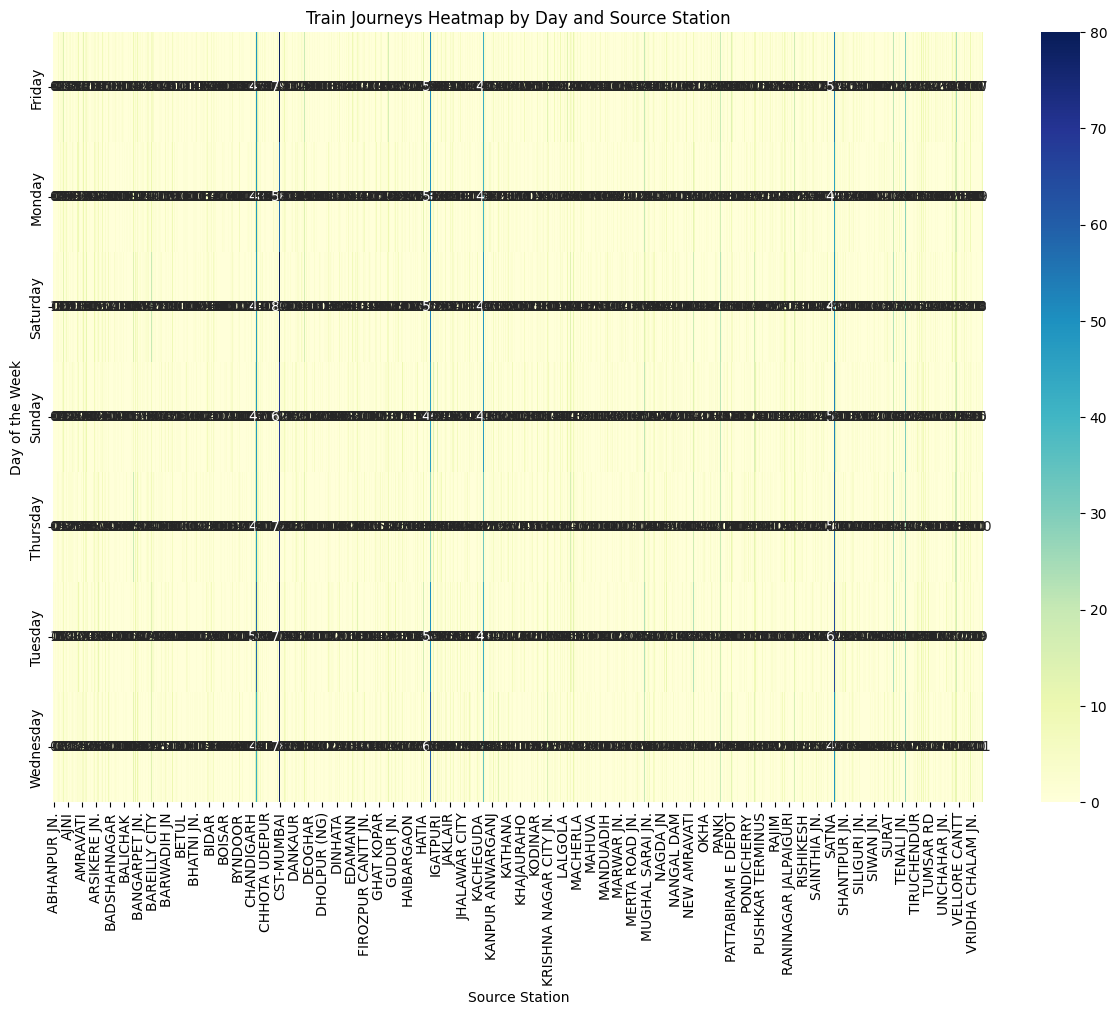

In [28]:
heatmap_data = pd.crosstab(df['days'], df['Source_Station_Name'])

plt.figure(figsize=(15, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Train Journeys Heatmap by Day and Source Station')
plt.xlabel('Source Station')
plt.ylabel('Day of the Week')
plt.show()

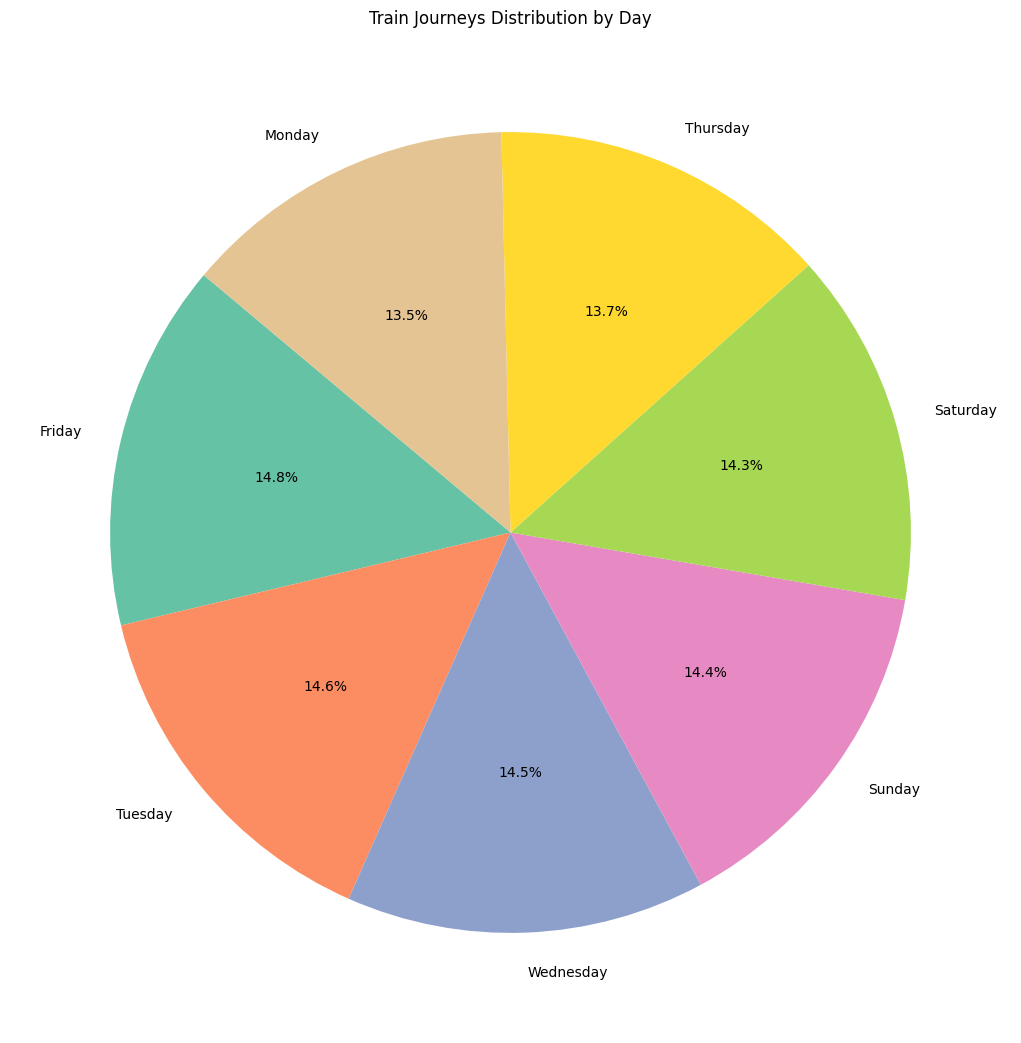

In [29]:
day_distribution = df['days'].value_counts()

plt.figure(figsize=(13, 13))
plt.pie(day_distribution, labels=day_distribution.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=140)
plt.title('Train Journeys Distribution by Day')
plt.show()

<Figure size 3000x1500 with 0 Axes>

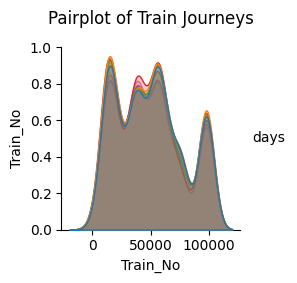

In [30]:
plt.figure(figsize=(30, 15))
sns.pairplot(df, hue='days')
plt.title('Pairplot of Train Journeys')
plt.show()

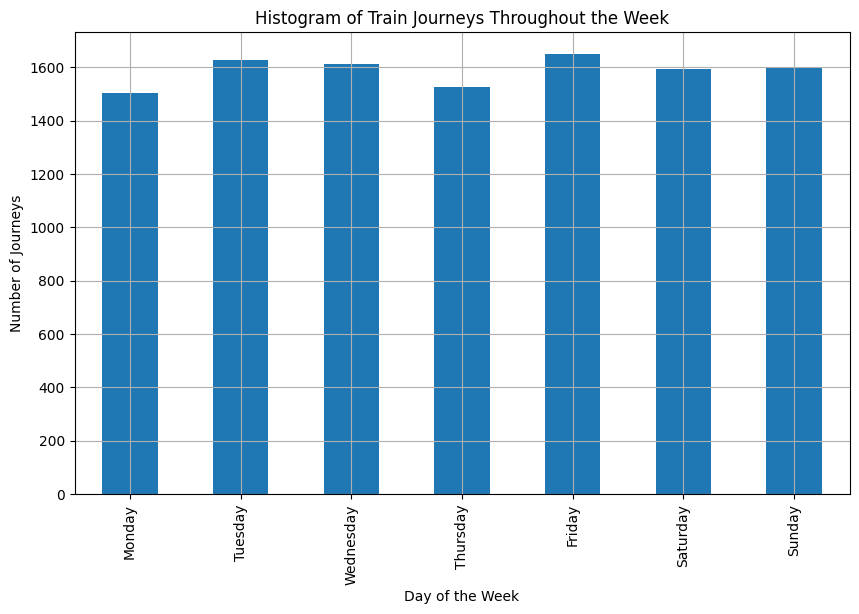

In [31]:
# Analyze the distribution of train journeys throughout the week. Visualize the results using bar plots or histograms.
plt.figure(figsize=(10, 6))
df['days'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).plot(kind='bar')
plt.title('Histogram of Train Journeys Throughout the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Journeys')
plt.grid(True)
plt.show()

### Task 3.2. Correlation and Insights

In [32]:
# Explore if there is any correlation between the number of trains and specific days of the week.
day_train_counts = df.groupby('days', observed=False).size()

days_mapping = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

numeric_days = day_train_counts.index.map(days_mapping)
numeric_days_series = pd.Series(numeric_days)
correlation = numeric_days_series.corr(pd.Series(day_train_counts.values))

print(f"Correlation between number of trains and days of the week: {correlation}")

Correlation between number of trains and days of the week: 0.3805757549252288


In [33]:
# Provide insights and recommendations based on the analysis.
# Peak days for train journeys
peak_days = day_distribution[day_distribution == day_distribution.max()].index

print(f"Peak days for train journeys: {', '.join(peak_days)}")

Peak days for train journeys: Friday


### LEVEL 4 - DATA VISUALISATION AND REPORTING

### Task 4.1. Visualization

<ipython-input-34-13a98b416568>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_stations.index, x=top_stations.values, palette='coolwarm')
<ipython-input-34-13a98b416568>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_distribution.index, y=day_distribution.values, palette='coolwarm')


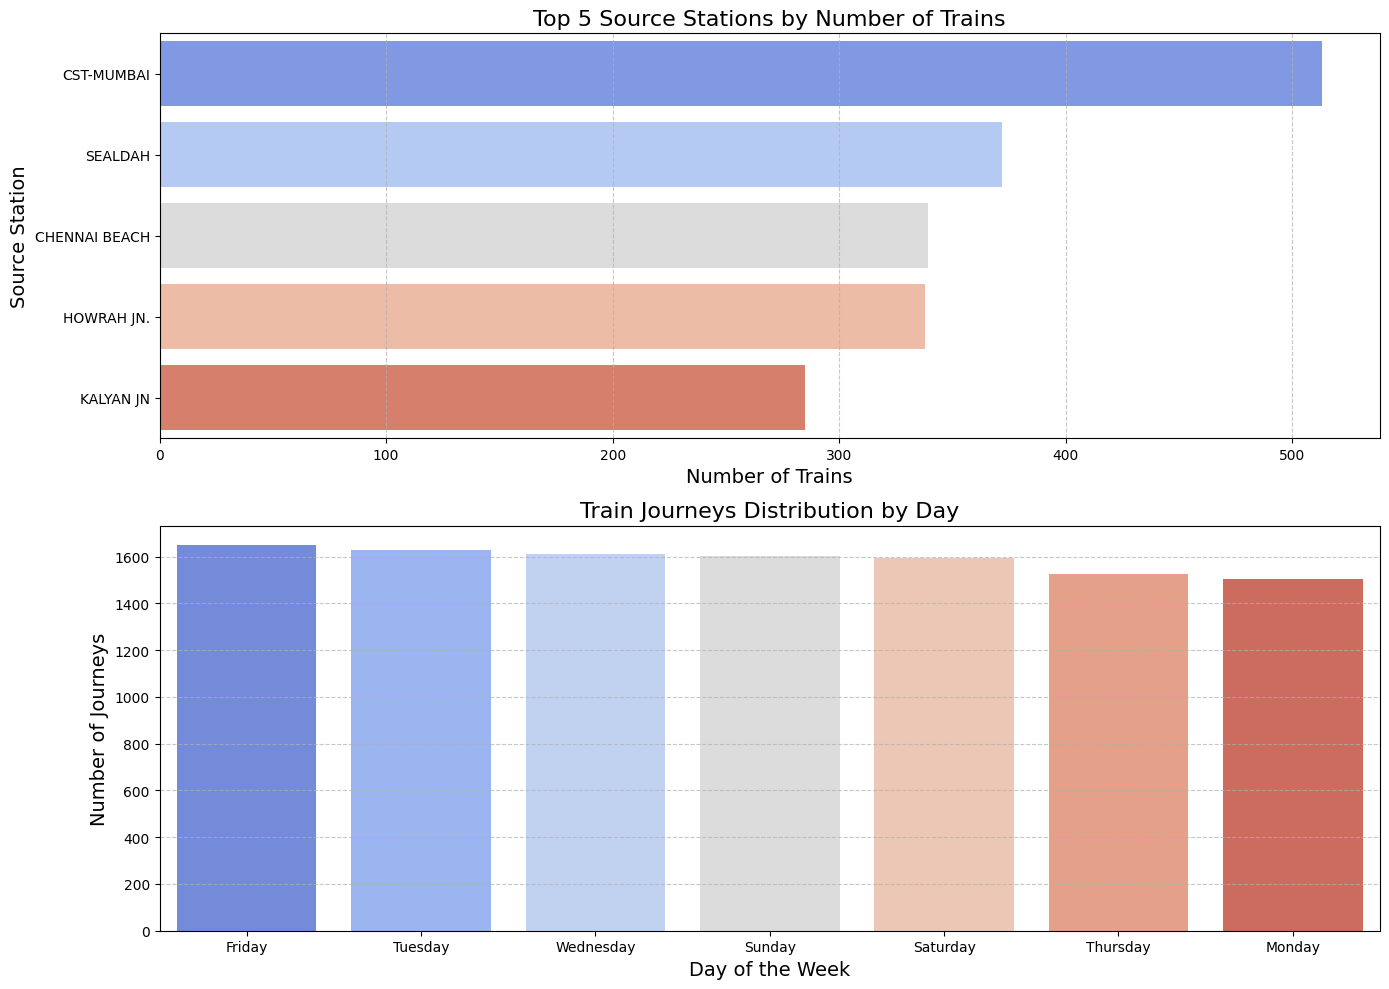

In [34]:
# Create visualizations (bar charts, line charts, heatmaps) to represent various aspects of the data (e.g., number of trains per station, day-wise distribution).
trains_by_source = df['Source_Station_Name'].value_counts()

day_distribution = df['days'].value_counts()

top_stations = trains_by_source.head(5)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
sns.barplot(y=top_stations.index, x=top_stations.values, palette='coolwarm')
plt.title('Top 5 Source Stations by Number of Trains', fontsize=16)
plt.xlabel('Number of Trains', fontsize=14)
plt.ylabel('Source Station', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplot(2, 1, 2)
sns.barplot(x=day_distribution.index, y=day_distribution.values, palette='coolwarm')
plt.title('Train Journeys Distribution by Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Number of Journeys', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

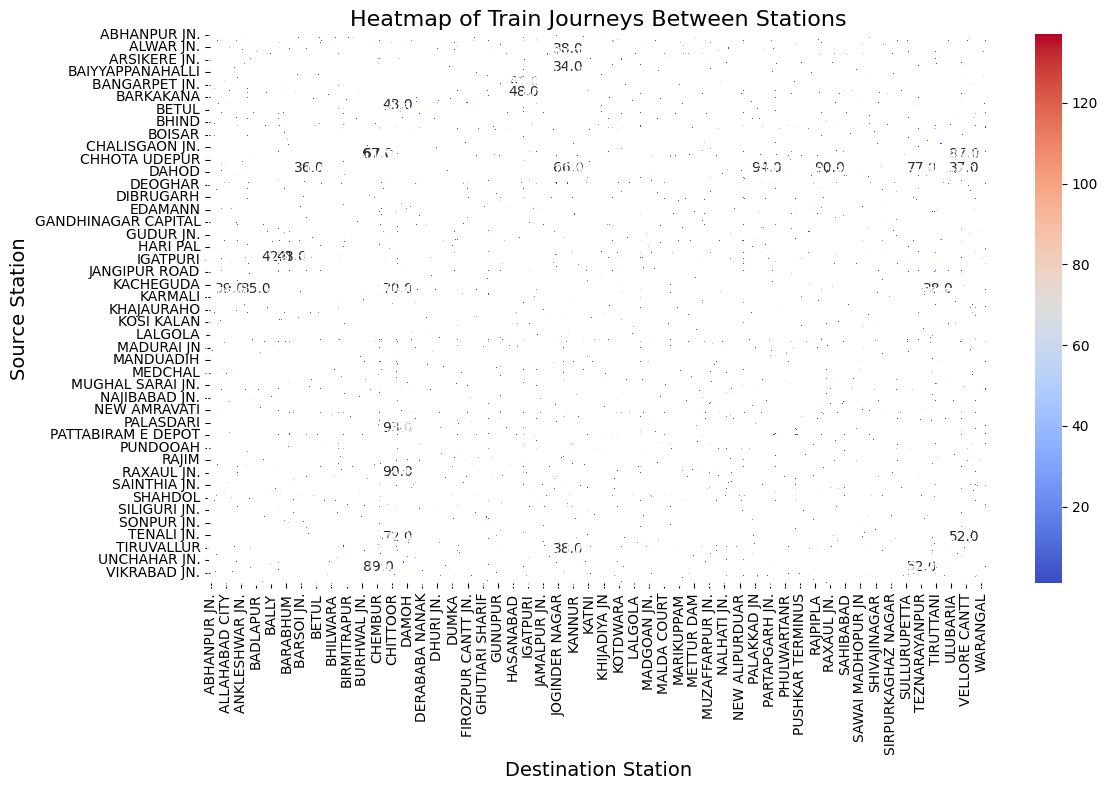

In [35]:
# Count of journeys between source and destination stations
journey_counts = df.groupby(['Source_Station_Name', 'Destination_Station_Name']).size().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(journey_counts, cmap='coolwarm', annot=True, fmt='.1f')
plt.title('Heatmap of Train Journeys Between Stations', fontsize=16)
plt.xlabel('Destination Station', fontsize=14)
plt.ylabel('Source Station', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

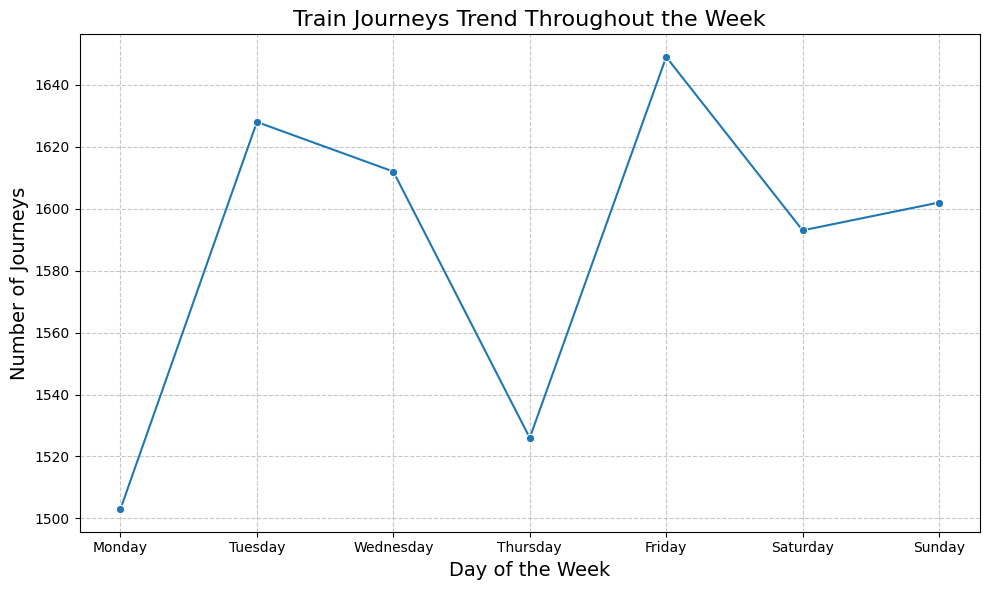

In [36]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['days'] = pd.Categorical(df['days'], categories=day_order, ordered=True)

day_distribution = df['days'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=day_distribution.index, y=day_distribution.values, marker='o', linestyle='-')
plt.title('Train Journeys Trend Throughout the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Number of Journeys', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()